# 05 — Stage 1 Trend Classifier (V5 Phase 3)

**BBL514E Pattern Recognition — Term Project**

Stage 1 trend classifier eğitildi: 4 ML model x 2 asset (BTC, ETH).
Bu notebook training sonuçlarını yükler ve değerlendirir.

## Konfigürasyon

- **Etiket:** ZigZag piecewise segmentation (deviation_pct=0.10, min_segment_days=10, range_amplitude=0.05)
- **Features:** 14 BTC/ETH OHLCV-based feature (returns, ADX, RSI, MACD, Bollinger, ATR, RV, volume z-score)
- **CV:** Walk-forward expanding-window. train_min=750, val=200, gap=10, step=200
- **Modeller:** XGBoost, LightGBM, Random Forest, MLP (StandardScaler on train fold only)
- **Hiperparametreler:** Sabit (Optuna search ileride opsiyonel)

## Decision gate (V5_PLAN.md)

Stage 1 OOF F1 macro ≥ 0.50 (chance level 0.33).

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True, "grid.alpha": 0.3})
proc = PROJECT_ROOT / "data" / "processed"
reports = PROJECT_ROOT / "reports" / "Phase3" 

## 1. Overall metrics — 4 model x 2 asset

In [2]:
overall = pd.read_csv(reports / "v5_p3_stage1_overall.csv")
overall_display = overall.copy()
for col in ["accuracy", "f1_macro", "f1_downtrend", "f1_range", "f1_uptrend"]:
    overall_display[col] = overall_display[col].round(4)
overall_display

,asset,model,n_folds,n_oof,accuracy,f1_macro,f1_downtrend,f1_range,f1_uptrend,elapsed_s
0,btc,xgboost,16,3200,0.5894,0.4563,0.5320,0.1509,0.6862,6.8
1,btc,lightgbm,16,3200,0.5778,0.4419,0.5102,0.1341,0.6814,12.6
2,btc,random_forest,16,3200,0.6206,0.4660,0.5519,0.1250,0.7211,13.6
3,btc,mlp,16,3200,0.5806,0.4609,0.5133,0.1927,0.6767,15.3
4,eth,xgboost,10,2000,0.5740,0.4953,0.5111,0.3077,0.6673,4.0
5,eth,lightgbm,10,2000,0.5655,0.4752,0.4926,0.2616,0.6714,7.6
6,eth,random_forest,10,2000,0.5860,0.4988,0.5128,0.2912,0.6923,8.2
7,eth,mlp,10,2000,0.5355,0.4543,0.4602,0.2672,0.6355,7.1


## 2. Per-fold F1 macro stability

In [3]:
metrics = pd.read_csv(reports / "v5_p3_stage1_metrics.csv", parse_dates=["val_start", "val_end"])
print(f"Total fold rows: {len(metrics)}")
metrics.groupby(["asset", "model"])["f1_macro"].agg(["mean", "std", "min", "max"]).round(4)

Total fold rows: 104


mean     std     min     max
asset model                                        
btc   lightgbm       0.4096  0.0839  0.2556  0.5480
      mlp            0.4284  0.0859  0.2350  0.5979
      random_forest  0.4282  0.0593  0.2582  0.5294
      xgboost        0.4160  0.0716  0.2670  0.5586
eth   lightgbm       0.4091  0.0769  0.2892  0.5250
      mlp            0.4107  0.0993  0.3065  0.5703
      random_forest  0.4234  0.0689  0.3181  0.5665
      xgboost        0.4240  0.0784  0.2648  0.5082

## 3. Confusion matrices (best model per asset)

BTC best: random_forest
ETH best: random_forest


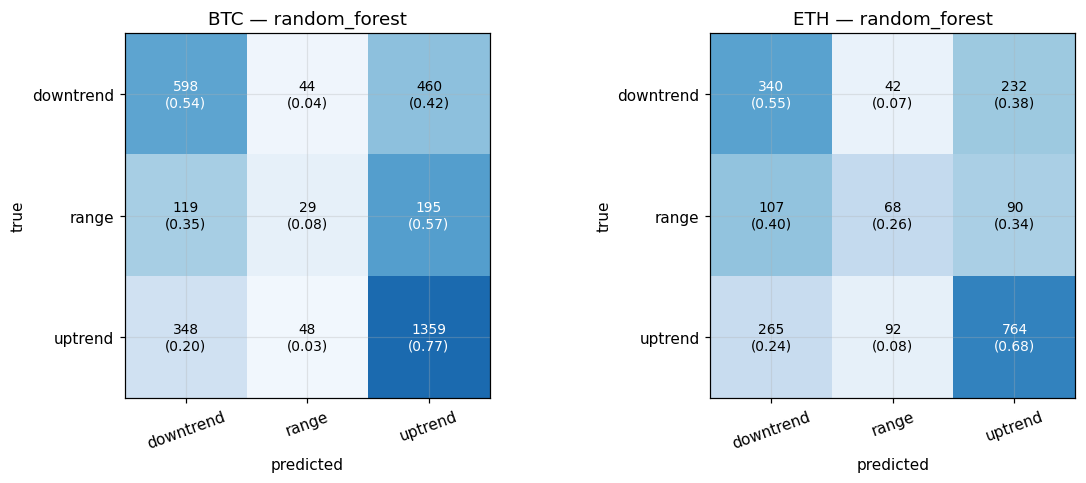

In [4]:
LABEL_TO_IDX = {"downtrend": 0, "range": 1, "uptrend": 2}
CLASS_NAMES = ["downtrend", "range", "uptrend"]

best_btc = overall[overall["asset"]=="btc"].sort_values("f1_macro").iloc[-1]["model"]
best_eth = overall[overall["asset"]=="eth"].sort_values("f1_macro").iloc[-1]["model"]
print(f"BTC best: {best_btc}\nETH best: {best_eth}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, asset, m in [(axes[0], "btc", best_btc), (axes[1], "eth", best_eth)]:
    oof = pd.read_csv(proc / f"{asset}_stage1_oof_{m}_v5.csv", index_col=0, parse_dates=True)
    yt = oof["true_label"].map(LABEL_TO_IDX).to_numpy()
    yp = oof["pred_label"].map(LABEL_TO_IDX).to_numpy()
    cm = confusion_matrix(yt, yp, labels=[0,1,2])
    cmn = cm / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f"{cm[i,j]}\n({cmn[i,j]:.2f})", ha="center", va="center",
                    color="white" if cmn[i,j]>0.5 else "black", fontsize=9)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(CLASS_NAMES, rotation=20); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    ax.set_title(f"{asset.upper()} — {m}")
plt.tight_layout(); plt.show()

## 4. OOF probability timeline (BTC, best model)

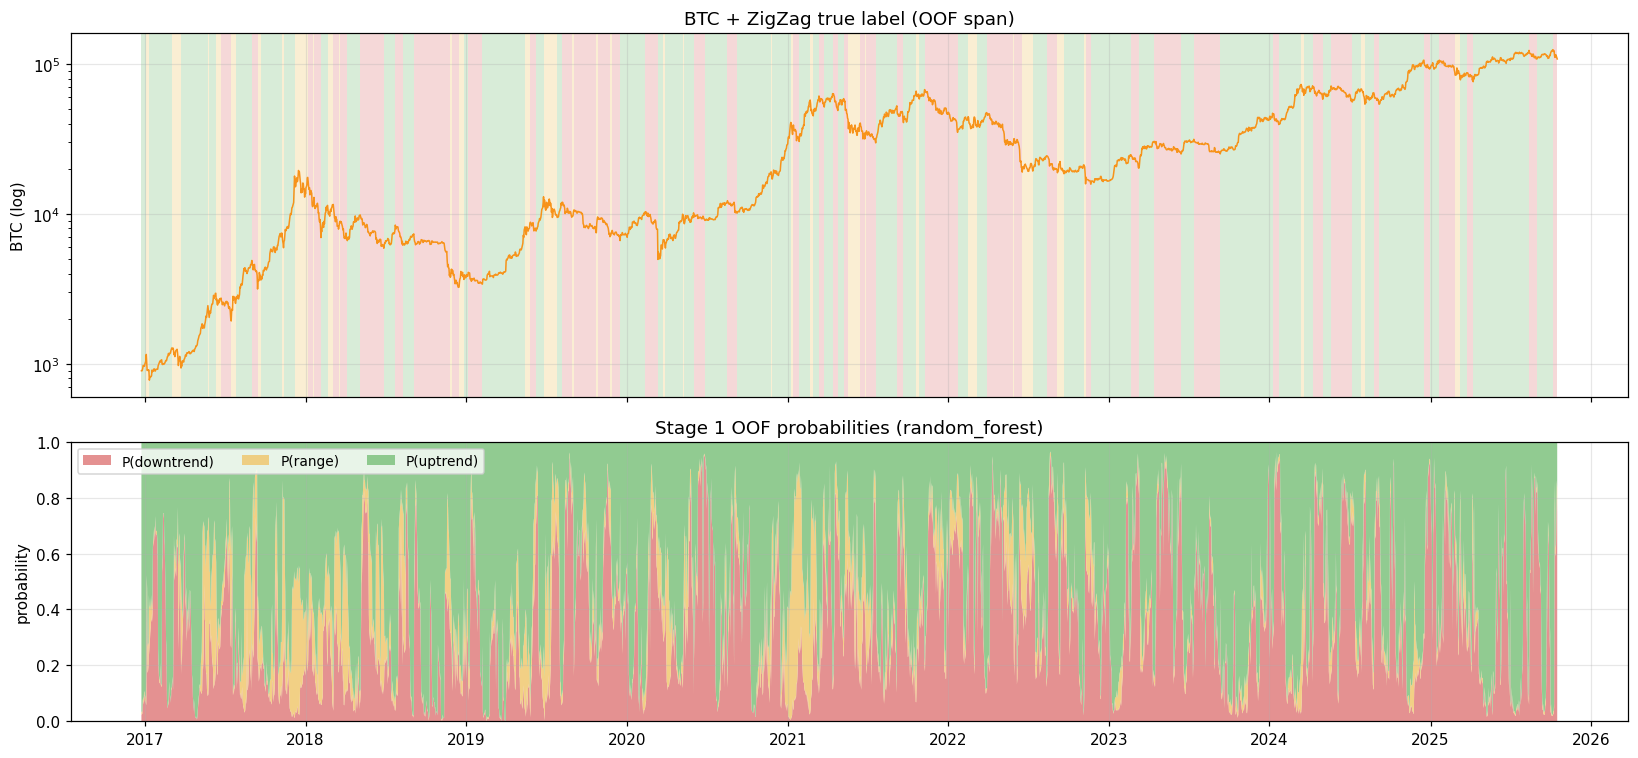

In [5]:
best = best_btc
oof_btc = pd.read_csv(proc / f"btc_stage1_oof_{best}_v5.csv", index_col=0, parse_dates=True)
btc = pd.read_csv(proc / "btc_aligned_v5.csv", index_col=0, parse_dates=True)
close = btc["Close"].reindex(oof_btc.index)

LABEL_COLORS = {"uptrend": "#7ec27e", "downtrend": "#e07e7e", "range": "#f0c870"}

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True,
                         gridspec_kw={"height_ratios": [1.3, 1.0]})
cur, start = oof_btc["true_label"].iloc[0], oof_btc.index[0]
for i in range(1, len(oof_btc)):
    v = oof_btc["true_label"].iloc[i]
    if v != cur:
        axes[0].axvspan(start, oof_btc.index[i], color=LABEL_COLORS[cur], alpha=0.30, lw=0)
        cur, start = v, oof_btc.index[i]
axes[0].axvspan(start, oof_btc.index[-1], color=LABEL_COLORS[cur], alpha=0.30, lw=0)
axes[0].semilogy(close.index, close.values, color="#F7931A", lw=1.0)
axes[0].set_ylabel("BTC (log)"); axes[0].set_title(f"BTC + ZigZag true label (OOF span)")

axes[1].stackplot(oof_btc.index,
    oof_btc["P_downtrend"], oof_btc["P_range"], oof_btc["P_uptrend"],
    colors=[LABEL_COLORS["downtrend"], LABEL_COLORS["range"], LABEL_COLORS["uptrend"]],
    labels=["P(downtrend)", "P(range)", "P(uptrend)"], alpha=0.85)
axes[1].set_ylim(0, 1); axes[1].set_ylabel("probability")
axes[1].set_title(f"Stage 1 OOF probabilities ({best})")
axes[1].legend(loc="upper left", ncol=3, fontsize=9)
plt.tight_layout(); plt.show()

## 5. Decision gate evaluation

| Asset | Best model | F1 macro | F1 down | F1 range | F1 up | Gate (≥ 0.50) |
|---|---|---|---|---|---|---|

In [6]:
for _, row in overall.sort_values(["asset", "f1_macro"], ascending=[True, False]).groupby("asset").head(1).reset_index(drop=True).iterrows():
    gate = "PASS" if row["f1_macro"] >= 0.50 else "BORDERLINE"
    print(f"{row['asset'].upper():4s}  {row['model']:14s}  F1m {row['f1_macro']:.4f}  "
          f"down {row['f1_downtrend']:.3f}  range {row['f1_range']:.3f}  up {row['f1_uptrend']:.3f}  "
          f"-> {gate}")

BTC   random_forest   F1m 0.4660  down 0.552  range 0.125  up 0.721  -> BORDERLINE
ETH   random_forest   F1m 0.4988  down 0.513  range 0.291  up 0.692  -> BORDERLINE


## Summary

**Bulgular:**
- Random Forest her iki asset için en iyi model (BTC F1m 0.466, ETH F1m 0.499)
- ETH genelde BTC'den daha iyi performans gösteriyor — range class ETH'te daha balanced (14.6% vs BTC'de 10.3%)
- **Range** sınıfı en zayıf (BTC F1 ≈ 0.13-0.19, ETH F1 ≈ 0.27-0.31) — sınıf imbalance + ZigZag retrospective tanım
- Chance level 0.33 üstünde 16-17 puan iyileşme → real prediction skill

**Stage 3'e soft fusion için OOF olasılık vektörleri (`P_downtrend, P_range, P_uptrend`) kaydedildi.**

Not: F1 ≥ 0.50 gate'i BTC için borderline (0.466). Pragmatik karar: range-class zayıflığı sınıf imbalance kaynaklı (yapısal), Stage 3 hierarchic mimari değer testi asıl gate. İlerliyoruz.